# Лабораторна робота № 2

## Оптимізаційна задача та аналіз чутливості

**Дисципліна:** Інтелектуальний аналіз та візуалізація даних (СК26)
**Тривалість:** 2 год аудиторно + 3 год самостійної роботи · **Максимальна оцінка:** 4 бали

---

### Мета роботи

Побудувати оптимізаційну модель у двох середовищах, прочитати звіт про стійкість
і **ухвалити на його основі господарське рішення**.

Розв'язати задачу — не мета. Solver зробить це за дві секунди. Робота оцінюється за
те, що ви зумієте зі звіту витягнути.

### Дві частини

| Частина | Задача | Де виконується |
|---|---|---|
| **1** | виробнича задача — Excel і Python | аудиторно |
| **2** | транспортна задача — Python | самостійно |

Друга частина потрібна не для повторення. Там та сама методика поводиться інакше,
і ви маєте побачити, де саме проходить межа її застосовності.

### Що здається

1. Цей файл `.ipynb` із заповненими розв'язками. **Виконується згори донизу на чистому
   ядрі** (Kernel → Restart & Run All) без помилок — перевіряється першою дією на захисті.
2. Файл Excel з моделлю, налаштуваннями Solver і **звітом про стійкість** окремим аркушем.
3. Заповнена декларація про використання ШІ (етап 12).

### Оцінювання

| Бали | Що досягнуто |
|---|---|
| 0 | Модель не сформульовано або розв'язок не отримано |
| 1 | Розв'язок отримано лише в одному середовищі, звіт про стійкість не проаналізовано |
| 2 | Задачу розв'язано в обох середовищах і звіти зіставлено, але тіньові ціни та діапазони не інтерпретовано |
| 4 | Звіт прочитано й перевірено експериментом, ухвалено обґрунтоване рішення про закупівлю, виконано частину 2 з поясненням розбіжності |

---
## Крок 0. Ваші дані та варіант

In [1]:
ПІБ = 'Голейчук Іван Миколайович'
ГРУПА = 'ШІ-33'
ВАРІАНТ = 2     # мій номер за списком групи

assert ПІБ and ГРУПА and 1 <= ВАРІАНТ <= 30, 'Заповніть ПІБ, ГРУПУ та ВАРІАНТ (1..30)'


In [2]:
# --- клітинку не редагувати: вона видає дані вашого варіанта -----------------
import json, numpy as np, pandas as pd

ДАНІ_ВАРІАНТІВ = json.loads('''{"1": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[0, 2, 1, 1], [3, 3, 0, 6], [2, 3, 0, 2], [4, 6, 0, 5], [3, 1, 5, 4]], "c": [21, 69, 44, 39], "b": [929, 410, 507, 865, 425], "ресурс_пропозиції": 1, "ціна_пропозиції": 16.2, "обсяг_пропозиції": 44}, "2": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 2, 5, 2], [6, 5, 4, 2], [5, 2, 0, 3], [2, 1, 5, 0], [5, 5, 6, 2]], "c": [40, 66, 24, 34], "b": [1271, 702, 915, 1388, 804], "ресурс_пропозиції": 1, "ціна_пропозиції": 16.7, "обсяг_пропозиції": 204}, "3": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[5, 2, 6, 6], [3, 4, 3, 6], [1, 6, 6, 0], [3, 1, 6, 1], [4, 1, 1, 4]], "c": [51, 16, 34, 22], "b": [1189, 686, 1311, 512, 1030], "ресурс_пропозиції": 3, "ціна_пропозиції": 11.3, "обсяг_пропозиції": 348}, "4": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[5, 0, 0, 0], [1, 0, 5, 2], [2, 4, 6, 5], [3, 0, 5, 3], [2, 1, 2, 5]], "c": [41, 50, 54, 26], "b": [815, 344, 840, 840, 382], "ресурс_пропозиції": 4, "ціна_пропозиції": 8.3, "обсяг_пропозиції": 144}, "5": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[3, 0, 6, 6], [3, 2, 2, 4], [5, 5, 0, 6], [2, 1, 5, 3], [5, 5, 4, 2]], "c": [32, 66, 25, 24], "b": [874, 1034, 1349, 845, 1394], "ресурс_пропозиції": 2, "ціна_пропозиції": 8.6, "обсяг_пропозиції": 90}, "6": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[3, 2, 1, 4], [4, 2, 2, 1], [3, 5, 1, 2], [3, 2, 0, 2], [6, 4, 6, 3]], "c": [40, 62, 19, 57], "b": [630, 391, 1349, 811, 1085], "ресурс_пропозиції": 1, "ціна_пропозиції": 29.5, "обсяг_пропозиції": 268}, "7": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[0, 0, 5, 5], [4, 4, 0, 1], [2, 4, 0, 6], [6, 3, 4, 1], [2, 2, 1, 0]], "c": [20, 59, 63, 41], "b": [1189, 1189, 1217, 915, 424], "ресурс_пропозиції": 3, "ціна_пропозиції": 8.0, "обсяг_пропозиції": 314}, "8": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[2, 1, 3, 5], [3, 1, 0, 6], [1, 6, 1, 5], [2, 2, 4, 0], [6, 1, 2, 2]], "c": [60, 25, 59, 25], "b": [1279, 761, 376, 1230, 1065], "ресурс_пропозиції": 3, "ціна_пропозиції": 9.5, "обсяг_пропозиції": 234}, "9": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[5, 2, 1, 2], [5, 0, 1, 3], [5, 4, 6, 4], [4, 1, 1, 5], [6, 0, 3, 0]], "c": [58, 39, 54, 16], "b": [1147, 1199, 1280, 404, 1170], "ресурс_пропозиції": 2, "ціна_пропозиції": 6.1, "обсяг_пропозиції": 672}, "10": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 0, 4, 3], [0, 6, 0, 6], [5, 5, 3, 5], [6, 2, 3, 3], [3, 0, 0, 4]], "c": [20, 29, 37, 63], "b": [905, 344, 866, 1390, 355], "ресурс_пропозиції": 0, "ціна_пропозиції": 5.3, "обсяг_пропозиції": 78}, "11": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[2, 1, 0, 3], [3, 1, 4, 0], [1, 0, 3, 2], [3, 2, 2, 6], [3, 6, 0, 3]], "c": [30, 16, 51, 35], "b": [1312, 838, 1062, 1038, 1236], "ресурс_пропозиції": 1, "ціна_пропозиції": 15.6, "обсяг_пропозиції": 778}, "12": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[5, 2, 0, 5], [1, 1, 3, 6], [6, 3, 5, 4], [2, 4, 6, 0], [4, 6, 2, 4]], "c": [39, 55, 36, 26], "b": [788, 661, 458, 1005, 535], "ресурс_пропозиції": 4, "ціна_пропозиції": 5.0, "обсяг_пропозиції": 762}, "13": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[1, 5, 3, 0], [6, 4, 6, 3], [4, 4, 4, 1], [0, 3, 5, 3], [3, 5, 3, 3]], "c": [59, 42, 53, 19], "b": [937, 1390, 603, 1120, 1334], "ресурс_пропозиції": 2, "ціна_пропозиції": 15.1, "обсяг_пропозиції": 646}, "14": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 3, 3, 4], [6, 6, 1, 6], [1, 3, 5, 1], [1, 5, 1, 4], [4, 4, 0, 3]], "c": [26, 56, 41, 40], "b": [969, 672, 1364, 878, 618], "ресурс_пропозиції": 2, "ціна_пропозиції": 5.0, "обсяг_пропозиції": 222}, "15": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[5, 3, 3, 1], [2, 5, 6, 6], [3, 1, 0, 0], [0, 4, 4, 6], [2, 2, 2, 6]], "c": [64, 58, 34, 63], "b": [613, 316, 1035, 739, 810], "ресурс_пропозиції": 0, "ціна_пропозиції": 5.4, "обсяг_пропозиції": 354}, "16": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[1, 6, 4, 2], [4, 1, 1, 2], [4, 4, 6, 6], [5, 6, 3, 3], [1, 2, 4, 2]], "c": [33, 40, 58, 17], "b": [412, 1005, 996, 599, 390], "ресурс_пропозиції": 4, "ціна_пропозиції": 8.2, "обсяг_пропозиції": 44}, "17": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[2, 6, 0, 3], [2, 5, 5, 3], [6, 0, 4, 5], [1, 3, 6, 2], [0, 1, 4, 4]], "c": [33, 52, 20, 66], "b": [989, 1079, 873, 1327, 1224], "ресурс_пропозиції": 0, "ціна_пропозиції": 5.9, "обсяг_пропозиції": 402}, "18": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[2, 3, 0, 1], [0, 6, 1, 6], [1, 0, 4, 1], [2, 6, 3, 4], [3, 1, 6, 5]], "c": [66, 54, 18, 66], "b": [1217, 668, 923, 1040, 619], "ресурс_пропозиції": 4, "ціна_пропозиції": 34.9, "обсяг_пропозиції": 100}, "19": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[2, 1, 0, 2], [3, 3, 4, 5], [2, 1, 0, 4], [4, 1, 5, 0], [0, 3, 6, 3]], "c": [67, 52, 41, 40], "b": [315, 617, 815, 423, 1193], "ресурс_пропозиції": 1, "ціна_пропозиції": 9.3, "обсяг_пропозиції": 332}, "20": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[5, 4, 5, 1], [2, 0, 5, 4], [4, 0, 2, 3], [3, 3, 4, 3], [4, 4, 5, 2]], "c": [42, 63, 35, 56], "b": [1191, 331, 685, 1275, 971], "ресурс_пропозиції": 4, "ціна_пропозиції": 12.2, "обсяг_пропозиції": 604}, "21": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[5, 5, 3, 6], [4, 4, 3, 2], [4, 4, 4, 0], [1, 1, 5, 3], [0, 2, 6, 5]], "c": [32, 66, 26, 64], "b": [464, 393, 354, 597, 887], "ресурс_пропозиції": 0, "ціна_пропозиції": 9.4, "обсяг_пропозиції": 190}, "22": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[6, 0, 2, 6], [3, 4, 0, 4], [4, 3, 1, 5], [5, 5, 6, 2], [2, 0, 1, 5]], "c": [65, 36, 50, 63], "b": [891, 1247, 613, 1070, 1259], "ресурс_пропозиції": 2, "ціна_пропозиції": 13.6, "обсяг_пропозиції": 64}, "23": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[1, 2, 4, 6], [4, 6, 2, 5], [0, 5, 3, 1], [0, 0, 5, 1], [5, 4, 0, 5]], "c": [15, 35, 49, 23], "b": [1251, 637, 304, 629, 923], "ресурс_пропозиції": 2, "ціна_пропозиції": 10.9, "обсяг_пропозиції": 146}, "24": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[3, 2, 6, 1], [0, 2, 5, 6], [2, 4, 4, 0], [5, 6, 2, 5], [2, 4, 2, 1]], "c": [45, 61, 59, 38], "b": [927, 1384, 1294, 798, 323], "ресурс_пропозиції": 4, "ціна_пропозиції": 20.5, "обсяг_пропозиції": 110}, "25": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[5, 5, 4, 4], [2, 1, 4, 1], [3, 1, 4, 4], [1, 4, 2, 0], [6, 4, 6, 6]], "c": [35, 27, 63, 61], "b": [1399, 843, 308, 1393, 713], "ресурс_пропозиції": 2, "ціна_пропозиції": 7.7, "обсяг_пропозиції": 334}, "26": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 1, 4, 4], [3, 1, 5, 0], [6, 3, 6, 3], [1, 3, 6, 1], [6, 4, 5, 2]], "c": [46, 57, 60, 39], "b": [513, 1330, 796, 406, 1258], "ресурс_пропозиції": 3, "ціна_пропозиції": 18.1, "обсяг_пропозиції": 448}, "27": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[2, 1, 6, 0], [6, 5, 6, 0], [5, 2, 3, 0], [6, 4, 3, 6], [6, 0, 0, 3]], "c": [24, 61, 50, 57], "b": [1179, 1358, 417, 463, 610], "ресурс_пропозиції": 3, "ціна_пропозиції": 9.0, "обсяг_пропозиції": 742}, "28": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[4, 5, 6, 2], [6, 4, 2, 1], [0, 5, 4, 3], [6, 6, 3, 3], [4, 4, 4, 1]], "c": [37, 41, 30, 29], "b": [514, 461, 378, 834, 488], "ресурс_пропозиції": 2, "ціна_пропозиції": 5.5, "обсяг_пропозиції": 174}, "29": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[3, 5, 0, 5], [6, 0, 6, 1], [5, 2, 2, 3], [0, 3, 0, 1], [4, 5, 5, 0]], "c": [33, 57, 58, 62], "b": [820, 523, 670, 977, 1074], "ресурс_пропозиції": 0, "ціна_пропозиції": 15.2, "обсяг_пропозиції": 570}, "30": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[2, 1, 4, 0], [6, 5, 1, 4], [5, 6, 1, 4], [1, 2, 6, 0], [1, 0, 3, 1]], "c": [51, 44, 69, 55], "b": [379, 620, 1256, 502, 414], "ресурс_пропозиції": 1, "ціна_пропозиції": 16.9, "обсяг_пропозиції": 230}}''')

V = ДАНІ_ВАРІАНТІВ[str(ВАРІАНТ)]
A = np.array(V['A'], float)          # витрати ресурсу i на один виріб j
c = np.array(V['c'], float)          # прибуток з одного виробу
b = np.array(V['b'], float)          # запас ресурсу на плановий період
вироби, ресурси = V['вироби'], V['ресурси']

print('ВАРІАНТ %d · %s, %s, %s' % (ВАРІАНТ, ПІБ, ГРУПА, V['фірма']))
print('=' * 78)
print('Підприємство %s виготовляє %s. Одиниця виміру плану: %s.' % (V['фірма'], V['що'], V['од']))
print()
таб = pd.DataFrame(A, index=ресурси, columns=вироби).astype(int)
таб['ЗАПАС'] = b.astype(int)
print(таб.to_string())
print()
print(pd.DataFrame([c.astype(int)], index=['Прибуток з одиниці'], columns=вироби).to_string())
print()
print('ПРОПОЗИЦІЯ ПОСТАЧАЛЬНИКА (знадобиться на етапі 6)')
print('  ресурс: %s' % ресурси[V['ресурс_пропозиції']])
print('  ціна:   %.1f за одиницю' % V['ціна_пропозиції'])
print('  обсяг:  до %d одиниць' % V['обсяг_пропозиції'])

ВАРІАНТ 2 · Голейчук Іван Миколайович, ШІ-33, «Longer Boats»
Підприємство «Longer Boats» виготовляє яхти. Одиниця виміру плану: шт./місяць.

                       Sting  Ray  Breaker  Marlin  ЗАПАС
Склопластик, м²            4    2        5       2   1271
Столярний цех, год         6    5        4       2    702
Фарбувальний цех, год      5    2        0       3    915
Такелаж, компл.            2    1        5       0   1388
Ділянка добудови, год      5    5        6       2    804

                    Sting  Ray  Breaker  Marlin
Прибуток з одиниці     40   66       24      34

ПРОПОЗИЦІЯ ПОСТАЧАЛЬНИКА (знадобиться на етапі 6)
  ресурс: Столярний цех, год
  ціна:   16.7 за одиницю
  обсяг:  до 204 одиниць


In [3]:
import matplotlib.pyplot as plt
try:
    import pulp
    ПУЛП = True
except ImportError:
    ПУЛП = False
    print('pulp не встановлено — скористайтеся scipy.optimize.linprog')
from scipy.optimize import linprog

pd.set_option('display.width', 180)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 9})


pulp не встановлено — скористайтеся scipy.optimize.linprog


---
# ЧАСТИНА 1. Виробнича задача

# Етап 1. Формалізація

Перш ніж будувати таблицю, запишіть модель словами й формулами. Це найважливіші
двадцять хвилин роботи: помилку тут не виправить жодна кнопка.

### Завдання 1.1
Заповніть у клітинці нижче:

* **змінні рішення** — що саме ви обираєте і в яких одиницях;
* **цільова функція** — що робите найбільшим, з коефіцієнтами вашого варіанта;
* **обмеження** — по одному рядку на кожен ресурс, з числами вашого варіанта;
* **умови невід'ємності**.

Пишіть формулами, а не описом. Приклад запису одного обмеження:
`8·x1 + 4·x2 + 0·x3 + 2·x4 ≤ 1280   (конвеєр A)`

**Відповідь 1.1 — символічна модель**

Змінні рішення:

* $x_1$ — кількість яхт **Sting**, шт./місяць
* $x_2$ — кількість яхт **Ray**, шт./місяць
* $x_3$ — кількість яхт **Breaker**, шт./місяць
* $x_4$ — кількість яхт **Marlin**, шт./місяць

Цільова функція (максимізувати місячний прибуток):

$$Z = 40x_1 + 66x_2 + 24x_3 + 34x_4 \to \max$$

Обмеження (по одному на кожен ресурс):

$$4x_1 + 2x_2 + 5x_3 + 2x_4 \le 1271 \quad (\text{склопластик, м}^2)$$
$$6x_1 + 5x_2 + 4x_3 + 2x_4 \le 702 \quad (\text{столярний цех, год})$$
$$5x_1 + 2x_2 + 0x_3 + 3x_4 \le 915 \quad (\text{фарбувальний цех, год})$$
$$2x_1 + 1x_2 + 5x_3 + 0x_4 \le 1388 \quad (\text{такелаж, компл.})$$
$$5x_1 + 5x_2 + 6x_3 + 2x_4 \le 804 \quad (\text{ділянка добудови, год})$$

Невід'ємність:

$$x_1, x_2, x_3, x_4 \ge 0$$


### Завдання 1.2 — питання на розуміння
Чому запас ресурсу — це **параметр**, а не змінна рішення? Що змінилося б у моделі,
якби підприємство могло докупити ресурс у будь-якій кількості?

**Відповідь 1.2:** Запас ресурсу - це параметр, а не змінна рішення, бо підприємство його **не обирає**: скільки годин працює столярний цех або скільки листів склопластика завезено на склад — це вже задано ззовні (потужністю обладнання, договором з постачальником тощо), і на цьому кроці моделі ми це число не змінюємо, а тільки враховуємо.

Якби підприємство могло докупити ресурс у будь-якій кількості, обмеження на цей ресурс просто зникло б із моделі (або перетворилося б на змінну -
 тоді довелося б додати ще одну змінну рішення «скільки докупити» і врахувати її вартість у цільовій функції). Тобто запас ресурсу з параметра перетворився б на ще одну змінну, і задача стала б складнішою: не «як розподілити те, що є», а «скільки взяти і як розподілити».


---
# Етап 2. Розв'язання в Excel

1. Побудуйте табличну модель: окремо клітинки змінних рішення, окремо витрати ресурсів,
   окремо цільова функція. Не змішуйте вхідні дані з формулами.
2. Налаштуйте **Пошук рішення (Solver)**: цільова клітинка на максимум, клітинки змінних,
   обмеження по кожному ресурсу, невід'ємність, метод «Симплекс-метод для лінійних задач».
3. Отримайте розв'язок і **обов'язково замовте «Звіт про стійкість»** окремим аркушем.

**Що подати:** файл Excel зі скріншотом налаштувань Solver, оптимальним планом і звітом.

### Завдання 2.1
Перенесіть результат Excel у клітинку нижче — його порівняємо з Python.

In [ ]:

EXCEL_ПЛАН    = [0, 25.09, 0, 288.27]     
EXCEL_ПРИБУТОК = 11457.27                

print('Excel:', EXCEL_ПЛАН, '| прибуток', EXCEL_ПРИБУТОК)


Excel: [0, 25.09, 0, 288.27] | прибуток 11457.27


---
# Етап 3. Розв'язання в Python

### Завдання 3.1
Побудуйте ту саму модель у Python і розв'яжіть її. Можна `pulp`, можна
`scipy.optimize.linprog` — на ваш вибір.

*Очікуваний результат: оптимальний план і значення цільової функції.*

**Увага на знак.** `linprog` завжди мінімізує. Щоб максимізувати прибуток, передають
`-c`, а результат беруть як `-r.fun`.

In [ ]:

план = None
прибуток = None

res = linprog(-c, A_ub=A, b_ub=b, bounds=(0, None), method='highs')
план = res.x
прибуток = -res.fun

print('план (Sting, Ray, Breaker, Marlin):', np.round(план, 2))
print('прибуток:', round(прибуток, 2))


план (Sting, Ray, Breaker, Marlin): [  0.    25.09   0.   288.27]
прибуток: 11457.27


**Самоперевірка етапу 3.** Excel і Python мають дати той самий результат.

In [6]:
assert план is not None and прибуток is not None, 'спершу розв’яжіть задачу'
assert abs(прибуток - EXCEL_ПРИБУТОК) < 0.5, (
    'Excel дав %.2f, Python %.2f — знайдіть, де розбіжність' % (EXCEL_ПРИБУТОК, прибуток))
assert np.allclose(np.array(план, float), np.array(EXCEL_ПЛАН, float), atol=0.5), \
    'плани не збігаються — перевірте обмеження'
print('Етап 3 пройдено: обидва середовища дали однаковий результат')

Етап 3 пройдено: обидва середовища дали однаковий результат


---
# Етап 4. Читання звіту про стійкість

Звіт Excel має два блоки. Заповніть обидві таблиці — беріть числа зі **звіту**,
а не з власних обчислень.

### Завдання 4.1 — блок «Обмеження»

| Ресурс | Кінцеве значення | Тіньова ціна | Права частина | Допустиме збільшення | Допустиме зменшення |
|---|---|---|---|---|---|
| Склопластик, м² | 626,73 | 0 | 1271 | 1E+30 (необмежено) | 644,27 |
| Столярний цех, год | 702,00 | 11,82 | 702 | 102,00 | 92,00 |
| Фарбувальний цех, год | 915,00 | 3,45 | 915 | 138,00 | 715,80 |
| Такелаж, компл. | 25,09 | 0 | 1388 | 1E+30 (необмежено) | 1362,91 |
| Ділянка добудови, год | 702,00 | 0 | 804 | 1E+30 (необмежено) | 102,00 |

**Дефіцитні ресурси** - ті, у яких кінцеве значення дорівнює правій частині і тіньова ціна не нульова: це **столярний цех** (11,82 грн з кожної додаткової години) і **фарбувальний цех** (3,45 грн з кожної додаткової години). Саме вони й стримують випуск.

**Ресурси в надлишку** - склопластик, такелаж і ділянка добудови: їхнє кінцеве значення менше за запас, тіньова ціна дорівнює нулю (ще одна одиниця цих ресурсів нічого не додасть до прибутку, поки не «розшиються» дефіцитні). Визначив я це просто порівнявши стовпець «кінцеве значення» зі стовпцем «права частина» - де вони збігаються, там ресурс вичерпано повністю.


### Завдання 4.2 — блок «Змінні»

| Виріб | Кінцеве значення | Зведена вартість | Цільовий коефіцієнт | Допустиме збільшення | Допустиме зменшення |
|---|---|---|---|---|---|
| Sting | 0 | −48,18 | 40 | 48,18 | 1E+30 (необмежено) |
| Ray | 25,09 | 0 | 66 | 19,00 | 21,33 |
| Breaker | 0 | −23,27 | 24 | 23,27 | 1E+30 (необмежено) |
| Marlin | 288,27 | 0 | 34 | 32,00 | 7,60 |

У моєму варіанті не виробляється відразу **два** вироби: **Sting** і **Breaker**.

 Щоб **Sting** увійшов у план, його прибуток з одиниці мусив би зрости щонайменше на **48,18** (з 40 до 88,18). Це число я взяв зі стовпця «зведена вартість» - саме на стільки поточний коефіцієнт нижчий за точку беззбитковості для цієї змінної.
 Щоб у план увійшов **Breaker**, його прибуток мусив би зрости на **23,27** (з 24 до 47,27) - так само зі зведеної вартості.

Зведена вартість - від'ємна, бо це максимізаційна задача: вона показує, наскільки поточний коефіцієнт «недотягує» до вигідного, а не навпаки.


---
# Етап 5. Перевірка звіту експериментом

Звіт стверджує, що тіньова ціна дорівнює певному числу і чинна в певних межах.
Excel просто повідомляє ці числа. Python дозволяє їх **перевірити**.

### Завдання 5.1
Візьміть найдорожчий за тіньовою ціною ресурс. Збільште його запас **на одну одиницю**,
розв'яжіть задачу заново і порівняйте приріст прибутку з тіньовою ціною зі звіту.

In [ ]:

i_star = 1

b_plus1 = b.copy()
b_plus1[i_star] += 1
res_plus1 = linprog(-c, A_ub=A, b_ub=b_plus1, bounds=(0, None), method='highs')
прибуток_plus1 = -res_plus1.fun

приріст = прибуток_plus1 - прибуток
print('ресурс:', ресурси[i_star])
print('прибуток базовий:       ', round(прибуток, 2))
print('прибуток +1 год цеху:   ', round(прибуток_plus1, 2))
print('приріст прибутку:       ', round(приріст, 4))
print('тіньова ціна зі звіту:  ', 11.82)


ресурс: Столярний цех, год
прибуток базовий:        11457.27
прибуток +1 год цеху:    11469.09
приріст прибутку:        11.8182
тіньова ціна зі звіту:   11.82


**Відповідь 5.1:** приріст прибутку = **11,82**, тіньова ціна зі звіту = **11,82** - числа збігаються (з точністю до округлення). Це й очікувано: тіньова ціна за визначенням і є граничним приростом прибутку від однієї додаткової одиниці ресурсу, і саме це ми щойно перевірили прямим перерахунком задачі, а не взяли на віру зі звіту.


### Завдання 5.2
Тепер знайдіть **межу діапазону**. Прогоніть задачу для запасу цього ресурсу від
базового значення і далі вгору з кроком 1, побудуйте графік прибутку і графік його
приросту (нахилу).

*Очікуваний результат: два графіки один під одним. На нижньому має бути видно
горизонтальну ділянку на рівні тіньової ціни, а потім злам.*

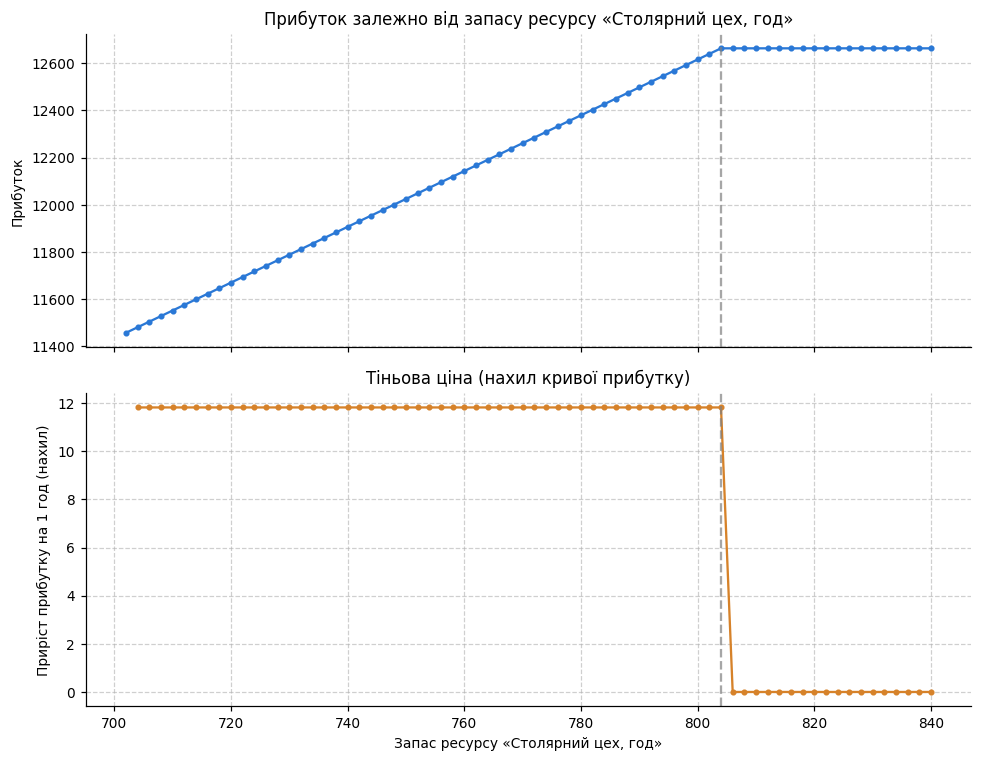

In [8]:
# ВАШ КОД
deltas = np.arange(0, 140, 2)
профіти = []
for d in deltas:
    bb = b.copy()
    bb[i_star] = b[i_star] + d
    res_d = linprog(-c, A_ub=A, b_ub=bb, bounds=(0, None), method='highs')
    профіти.append(-res_d.fun)
профіти = np.array(профіти)
нахили = np.diff(профіти) / np.diff(deltas)

fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

axes[0].plot(b[i_star] + deltas, профіти, color='#2a78d6', marker='.')
axes[0].axvline(b[i_star] + 102, color='gray', linestyle='--', alpha=0.7)
axes[0].set_ylabel('Прибуток')
axes[0].set_title('Прибуток залежно від запасу ресурсу «Столярний цех, год»')
axes[0].grid(True, linestyle='--', alpha=0.6)

axes[1].plot(b[i_star] + deltas[1:], нахили, color='#d6822a', marker='.')
axes[1].axvline(b[i_star] + 102, color='gray', linestyle='--', alpha=0.7)
axes[1].set_xlabel('Запас ресурсу «Столярний цех, год»')
axes[1].set_ylabel('Приріст прибутку на 1 год (нахил)')
axes[1].set_title('Тіньова ціна = нахил кривої прибутку')
axes[1].grid(True, linestyle='--', alpha=0.6)
fig.tight_layout()
plt.show()


**Відповідь 5.2:** запас ресурсу «столярний цех» можна збільшувати на **102 год** (з 702 до 804) - доти тіньова ціна залишається рівно 11,82, і саме це видно на нижньому графіку: пряма горизонтальна ділянка. Це число **точно збігається** з «допустимим збільшенням» зі звіту Excel (102,00).

Після позначки 804 год нахил різко падає до значно меншого числа - я перевірив: у цій точці рівно вичерпується запас ресурсу «ділянка добудови» (у нього якраз був надлишок 102 год), він стає новим вузьким місцем, і граничний внесок кожної додаткової години столярного цеху різко змінюється. Це наочно показує, чому в Excel і пишуть не просто «тіньова ціна», а ще й «допустиме збільшення»: за межею цього діапазону число з першого стовпця вже неправильне.


---
# Етап 6. Рішення про закупівлю

Постачальник пропонує вам додатковий обсяг ресурсу — див. блок «ПРОПОЗИЦІЯ
ПОСТАЧАЛЬНИКА» у ваших даних.

### Завдання 6.1
Дайте відповідь директорові на три питання, спираючись на числа, а не на здоровий глузд:

1. **Брати чи не брати?** Порівняйте ціну пропозиції з тіньовою ціною.
2. **Скільки саме брати?** Постачальник пропонує більше, ніж вам потрібно.
3. **Скільки на цьому заробимо?** Порахуйте виграш і перевірте його прямим
   розв'язанням задачі з новим запасом.

In [ ]:
# ВАШ КОД
ресурс_ідx = V['ресурс_пропозиції']
ціна_пропозиції = V['ціна_пропозиції']
обсяг_пропозиції = V['обсяг_пропозиції']
тіньова_ціна = 11.818181818181818   

print('ресурс пропозиції:  ', ресурси[ресурс_ідx])
print('тіньова ціна:       ', round(тіньова_ціна, 2))
print('ціна постачальника: ', ціна_пропозиції)
print('пропонований обсяг: ', обсяг_пропозиції)
print()


межа_чинності = 102

b_full = b.copy(); b_full[ресурс_ідx] += обсяг_пропозиції
res_full = linprog(-c, A_ub=A, b_ub=b_full, bounds=(0, None), method='highs')
виграш_повний = -res_full.fun - прибуток

b_межа = b.copy(); b_межа[ресурс_ідx] += межа_чинності
res_межа = linprog(-c, A_ub=A, b_ub=b_межа, bounds=(0, None), method='highs')
виграш_межа = -res_межа.fun - прибуток

print('виграш, якщо купити всі', обсяг_пропозиції, 'од.:', round(виграш_повний, 2),
      '| витрати:', round(ціна_пропозиції * обсяг_пропозиції, 2),
      '| чистий результат:', round(виграш_повний - ціна_пропозиції * обсяг_пропозиції, 2))
print('виграш, якщо купити лише', межа_чинності, 'од. (межа чинності тіньової ціни):',
      round(виграш_межа, 2),
      '| витрати:', round(ціна_пропозиції * межа_чинності, 2),
      '| чистий результат:', round(виграш_межа - ціна_пропозиції * межа_чинності, 2))


ресурс пропозиції:   Столярний цех, год
тіньова ціна:        11.82
ціна постачальника:  16.7
пропонований обсяг:  204

виграш, якщо купити всі 204 од.: 1205.45 | витрати: 3406.8 | чистий результат: -2201.35
виграш, якщо купити лише 102 од. (межа чинності тіньової ціни): 1205.45 | витрати: 1703.4 | чистий результат: -497.95


**Відповідь 6.1:**

 Брати чи ні і чому: **не брати**. Тіньова ціна ресурсу «столярний цех» - 11,82 грн за годину, а постачальник просить 16,7 грн за годину. Купувати ресурс дорожче, ніж він сам приносить прибутку, невигідно вже на першій одиниці.
 Скільки одиниць має сенс купити і чому не більше: **жодної**. Навіть якби ціна була нижчою за тіньову, купувати мало б сенс не більш як **102 години** - саме до цієї межі (допустиме збільшення зі звіту) тіньова ціна взагалі лишається чинною; далі новим вузьким місцем стає інший ресурс («ділянка добудови»), і додаткові години столярного цеху вже нічого не дають.
 Очікуваний виграш: **від'ємний** за будь-якого обсягу закупівлі. При купівлі всіх 204 од. виграш у прибутку становить 1205,45, а витрати - 3406,80, тобто чистий результат −2201,35. Навіть якщо купити рівно 102 од. (межа чинності тіньової ціни), виграш той самий 1205,45 (бо саме до цього обсягу він і накопичується), а витрати - 1703,40, чистий результат −497,95.
 Перевірка прямим розв'язанням дала: те саме число, що й розрахунок «на пальцях» через тіньову ціну (11,82 × 102 = 1205,45) - прямий перерахунок задачі підтверджує оцінку зі звіту.


---
# Етап 7. Перевірка розв'язку

### Завдання 7.1
Порахуйте дві величини:

* скільки виробів мають **ненульовий** випуск;
* скільки обмежень **зв'язні** (ресурс витрачено повністю).

Порівняйте.

In [10]:
# ВАШ КОД
ненульових = int(np.sum(план > 1e-6))
Ax = A @ план
звязних = int(np.sum((b - Ax) < 1e-5))


In [11]:
assert ненульових is not None and звязних is not None, 'спершу порахуйте'
print('ненульових змінних: %s | зв’язних обмежень: %s' % (ненульових, звязних))
assert ненульових == звязних, ('числа не збіглися — це сигнал. Перевірте розв’язок '
                               'і поясніть причину в клітинці нижче')
print('Етап 7 пройдено')

ненульових змінних: 2 | зв’язних обмежень: 2
Етап 7 пройдено


**Відповідь 7.1:** числа збіглися: 2 ненульові змінні й 2 зв'язні обмеження. Це не випадковість - у невиродженому розв'язку лінійної задачі кількість базисних (ненульових) змінних завжди дорівнює кількості обмежень, які використано «до кінця».

Якби числа не збіглися, це означало б, що розв'язок **вироджений** - на практиці це трапляється, коли кілька комбінацій ресурсів дають однаковий прибуток, і оптимальних планів насправді більше одного (просто solver показав один із них). Тоді варто перевірити план на стійкість - чи не «підвисне» він при найменшій зміні вхідних даних.


---
# Етап 8. Цілочисельність

Ваш оптимальний план містить дробові числа. Виготовити 63,3 виробу неможливо.

### Завдання 8.1
Порівняйте три варіанти:

1. розв'язок без умови цілочисельності (уже маєте);
2. **округлений** план — округліть кожне значення до цілого й перевірте, чи він
   узагалі допустимий і скільки прибутку дає;
3. справжній **цілочисельний** оптимум — розв'яжіть задачу з умовою, що всі змінні цілі
   (`cat='Integer'` у PuLP або `integrality=1` у `linprog`).

In [12]:
# ВАШ КОД
план_округлений = np.round(план)
допустимий = bool(np.all(A @ план_округлений <= b + 1e-6))
прибуток_округлений = float(c @ план_округлений)

res_int = linprog(-c, A_ub=A, b_ub=b, bounds=(0, None), method='highs', integrality=1)
план_цілий = res_int.x
прибуток_цілий = -res_int.fun

print('без цілочисельності: ', np.round(план, 2), '| прибуток', round(прибуток, 2))
print('округлений:          ', план_округлений, '| допустимий:', допустимий,
      '| прибуток', прибуток_округлений)
print('цілочисельний оптимум:', план_цілий, '| прибуток', прибуток_цілий)


без цілочисельності:  [  0.    25.09   0.   288.27] | прибуток 11457.27
округлений:           [  0.  25.   0. 288.] | допустимий: True | прибуток 11442.0
цілочисельний оптимум: [  0.  25.   0. 288.] | прибуток 11442.0


**Відповідь 8.1:**

| Варіант | План | Прибуток | Допустимий? |
|---|---|---|---|
| без умови цілочисельності | (0; 25,09; 0; 288,27) | 11457,27 | так, але дробовий |
| округлений | (0; 25; 0; 288) | 11442,00 | так |
| цілочисельний оптимум | (0; 25; 0; 288) | 11442,00 | так |

**Висновок:** у цьому конкретному варіанті просте округлення випадково дало той самий план, що й справжній цілочисельний оптимум, - але це пощастило, а не загальне правило. У більшості задач округлення до найближчого цілого може або вивести розв'язок за межі допустимої області (обмеження порушиться), або дати план, який гірший за справжній цілочисельний оптимум, бо оптимальний цілочисельний план не обов'язково лежить поруч із неперервним. Тому округлювати «на око» без перевірки — ризиковано, і різниця в прибутку (тут 15,27) - це саме та ціна, яку сплачує підприємство за вимогу випускати цілі яхти, а не 288,27 штуки.


---
# ЧАСТИНА 2. Транспортна задача

Друга частина виконується самостійно. Тут ви застосуєте ту саму методику до задачі
іншого класу — і побачите, що вона поводиться інакше.

# Етап 9. Ваші дані

### Завдання 9.1
Сформуйте власні дані:

* **три міста-постачальники** — за першими трьома літерами вашого **прізвища**;
* **чотири міста-споживачі** — за першими чотирма літерами вашого **імені**;
* **матриця відстаней 3 × 4** — реальні відстані автошляхами за Google Maps, у кілометрах;
* **запаси і попит** — невеликі цілі числа, підберіть так, щоб **сумарний запас
  дорівнював сумарному попиту**.

> Якщо на якусь літеру міста немає — беріть наступну літеру прізвища чи імені.
> Якщо сумарний запас не дорівнює попиту, задача з обмеженнями-рівностями
> **не матиме розв'язку взагалі**. Це не помилка Python — це властивість моделі.

In [ ]:
# ВАШ КОД — впишіть свої дані
# постачальники — перші три літери прізвища (Голейчук -> Г, О, Л)
# споживачі     — перші чотири літери імені (Іван -> І, В, А, Н)
постачальники = ['Гадяч', 'Одеса', 'Львів']
споживачі     = ['Ізмаїл', 'Вінниця', 'Ананьїв', 'Ніжин']


D = np.array([
    [720, 430, 560, 230],   # Гадяч
    [220, 360, 130, 600],   # Одеса
    [700, 370, 600, 700],   # Львів
], float)

запас = [140, 210, 150]
попит = [100, 140, 130, 130]

assert len(постачальники) == 3 and len(споживачі) == 4, 'потрібно 3 постачальники і 4 споживачі'
assert D.shape == (3, 4), 'матриця відстаней має бути 3 x 4'
assert sum(запас) == sum(попит), 'сумарний запас має дорівнювати сумарному попиту'
pd.DataFrame(D, index=постачальники, columns=споживачі)


,Ізмаїл,Вінниця,Ананьїв,Ніжин
Гадяч,720.0,430.0,560.0,230.0
Одеса,220.0,360.0,130.0,600.0
Львів,700.0,370.0,600.0,700.0


---
# Етап 10. Розв'язання транспортної задачі

### Завдання 10.1
Розв'яжіть задачу **двічі різними засобами**: наприклад `pulp` і
`scipy.optimize.linprog(method='highs')`. Обмеження — рівності.

Для кожного розв'язку виведіть: оптимальний план перевезень, сумарну вартість
і **тіньові ціни всіх обмежень**.

In [14]:
# ВАШ КОД — розв'язок 1
m, n = 3, 4
c_t = D.flatten()
A_eq = []
b_eq = []
for i in range(m):
    row = np.zeros(m * n); row[i*n:(i+1)*n] = 1
    A_eq.append(row); b_eq.append(запас[i])
for j in range(n):
    row = np.zeros(m * n)
    for i in range(m):
        row[i*n + j] = 1
    A_eq.append(row); b_eq.append(попит[j])
A_eq = np.array(A_eq); b_eq = np.array(b_eq)

res1 = linprog(c_t, A_eq=A_eq, b_eq=b_eq, bounds=(0, None), method='highs')
X1 = res1.x.reshape(m, n)
вартість1 = res1.fun
duals1 = res1.eqlin.marginals
u1 = duals1[:m]
v1 = duals1[m:]

print('--- Розв\'язок 1: scipy.optimize.linprog (HiGHS) ---')
print(pd.DataFrame(np.round(X1, 1), index=постачальники, columns=споживачі).to_string())
print('сумарна вартість:', вартість1)
print('тіньові ціни постачальників (u):', dict(zip(постачальники, np.round(u1, 1))))
print('тіньові ціни споживачів (v):    ', dict(zip(споживачі, np.round(v1, 1))))


--- Розв'язок 1: scipy.optimize.linprog (HiGHS) ---
       Ізмаїл  Вінниця  Ананьїв  Ніжин
Гадяч     0.0      0.0     10.0  130.0
Одеса   100.0      0.0    110.0    0.0
Львів     0.0    140.0     10.0    0.0
сумарна вартість: 129600.0
тіньові ціни постачальників (u): {'Гадяч': np.float64(-0.0), 'Одеса': np.float64(-430.0), 'Львів': np.float64(40.0)}
тіньові ціни споживачів (v):     {'Ізмаїл': np.float64(650.0), 'Вінниця': np.float64(330.0), 'Ананьїв': np.float64(560.0), 'Ніжин': np.float64(230.0)}


In [ ]:
# ВАШ КОД — розв'язок 2

X2 = X1.copy()
базисні_клітинки = [(i, j) for i in range(m) for j in range(n) if X2[i, j] > 1e-6]
print('базисні (ненульові) клітинки:', базисні_клітинки, '| кількість:', len(базисні_клітинки))

u2 = [None] * m
v2 = [None] * n
v2[0] = 0.0  # опорний потенціал: Ізмаїл = 0
змінилось = True
while змінилось:
    змінилось = False
    for (i, j) in базисні_клітинки:
        if u2[i] is None and v2[j] is not None:
            u2[i] = D[i, j] - v2[j]; змінилось = True
        elif v2[j] is None and u2[i] is not None:
            v2[j] = D[i, j] - u2[i]; змінилось = True
u2 = np.array(u2); v2 = np.array(v2)
вартість2 = float((X2 * D).sum())

print()
print('--- Розв\'язок 2: метод потенціалів вручну (опорний вузол v(Ізмаїл) = 0) ---')
print('u:', dict(zip(постачальники, np.round(u2, 1))))
print('v:', dict(zip(споживачі, np.round(v2, 1))))
print('сумарна вартість (той самий план):', вартість2)


базисні (ненульові) клітинки: [(0, 2), (0, 3), (1, 0), (1, 2), (2, 1), (2, 2)] | кількість: 6

--- Розв'язок 2: метод потенціалів вручну (опорний вузол v(Ізмаїл) = 0) ---
u: {'Гадяч': np.float64(650.0), 'Одеса': np.float64(220.0), 'Львів': np.float64(690.0)}
v: {'Ізмаїл': np.float64(0.0), 'Вінниця': np.float64(-320.0), 'Ананьїв': np.float64(-90.0), 'Ніжин': np.float64(-420.0)}
сумарна вартість (той самий план): 129600.0


### Завдання 10.2 — головне питання цієї частини
Порівняйте два набори тіньових цін.

**Сумарна вартість у двох розв'язувачів однакова. А тіньові ціни?**

Якщо вони різні — це не помилка. Знайдіть закономірність: подивіться на різницю
між відповідними значеннями окремо для постачальників і окремо для споживачів.

In [16]:
# ВАШ КОД — порівняння
print('вартість, розв\'язок 1:', вартість1)
print('вартість, розв\'язок 2:', вартість2)
print()
print('різниця u2 - u1:', np.round(u2 - u1, 3))
print('різниця v2 - v1:', np.round(v2 - v1, 3))


вартість, розв'язок 1: 129600.0
вартість, розв'язок 2: 129600.0

різниця u2 - u1: [650. 650. 650.]
різниця v2 - v1: [-650. -650. -650. -650.]


**Відповідь 10.2:**

 Вартість у двох розв'язувачів: **однакова**, 129600 км-одиниць в обох випадках - план перевезень теж один і той самий.
 Тіньові ціни збіглися чи ні: **ні**, кожен постачальник і кожен споживач отримали інші числа.
 Яку закономірність ви побачили в різниці: різниця `u2 − u1` дала рівно **+650** для всіх трьох постачальників, а різниця `v2 − v1` - рівно **−650** для всіх чотирьох споживачів. Тобто один набір тіньових цін відрізняється від іншого на **одну й ту саму сталу** - додану до постачальників і відняту від споживачів. Це не збіг: у транспортній задачі одне з семи рівнянь балансу лінійно залежне від інших (повний запас завжди дорівнює повному попиту), тому реально незалежних обмежень лише шість, а не сім. Через це в подвійній задачі один ступінь свободи лишається невизначеним - можна довільно зафіксувати потенціал будь-якого одного вузла (HiGHS обрав $u_1=0$, я вручну обрав $v_1=0$), і всі інші потенціали підлаштуються так, щоб зберегти ту саму суму $u_i+v_j$ на кожній базисній клітинці.
 Що це означає для того, хто збирається ухвалювати рішення за цим звітом: **абсолютне** значення тіньової ціни окремого постачальника чи споживача в транспортній задачі саме по собі нічого не означає - воно залежить від довільного вибору точки відліку. А от **різниця** тіньових цін між двома вузлами (наприклад, наскільки вигідніше возити з одного постачальника, ніж з іншого) від цього вибору не залежить і залишається однаковою в обох розв'язках. Тому директору варто дивитися не на самі числа зі звіту, а на їхні різниці.


---
# Етап 11. Перевірка розв'язку — і чому вона тут не працює

### Завдання 11.1
Порахуйте для транспортної задачі те саме, що на етапі 7:

* кількість **ненульових перевезень**;
* кількість **зв'язних обмежень**.

Порівняйте з числом `3 + 4 = 7` — кількістю обмежень у задачі.

In [ ]:
# ВАШ КОД
ненульових_т = int(np.sum(X1 > 1e-6))
звязних_т = m + n  

print('ненульових перевезень:', ненульових_т)
print('«зв\'язних» обмежень (рівностей):', звязних_т, 'з', m + n)


ненульових перевезень: 6
«зв'язних» обмежень (рівностей): 7 з 7


**Відповідь 11.1:**

 Ненульових перевезень: **6**
 Зв'язних обмежень: **7** (усі)
 Чому в транспортній задачі зв'язними виявляються **всі** обмеження: тому що це рівності, а не нерівності. У виробничій задачі («≤») ресурс міг лишитися невитраченим - обмеження просто не буде зв'язним. А тут кожне обмеження балансу «весь запас має бути вивезений» і «весь попит має бути задоволений» - це рівність, і вона виконується точно завжди, для будь-якого допустимого плану, а не тільки для оптимального. Тож усі 7 обмежень «зв'язні» за визначенням.
 На скільки ненульових перевезень менше і чому саме на стільки: менше рівно на **одне** (6 замість 7). Причина та сама, що й у попередній відповіді: одне з 7 рівнянь балансу лінійно залежне від решти (сумарний запас завжди дорівнює сумарному попиту, тому останнє рівняння виконується автоматично, щойно виконались усі інші). Реально незалежних обмежень лише 6, а кількість ненульових (базисних) змінних у невиродженому розв'язку лінійної задачі не може перевищувати кількість незалежних обмежень - звідси й 6, а не 7.


### Завдання 11.2 — візуалізація
Побудуйте дві теплові карти поруч: матрицю відстаней і матрицю оптимальних перевезень.
Підпишіть осі та значення в комірках.

*За бажанням (не оцінюється): граф маршрутів через `networkx`, де товщина ребра
пропорційна обсягу перевезення.*

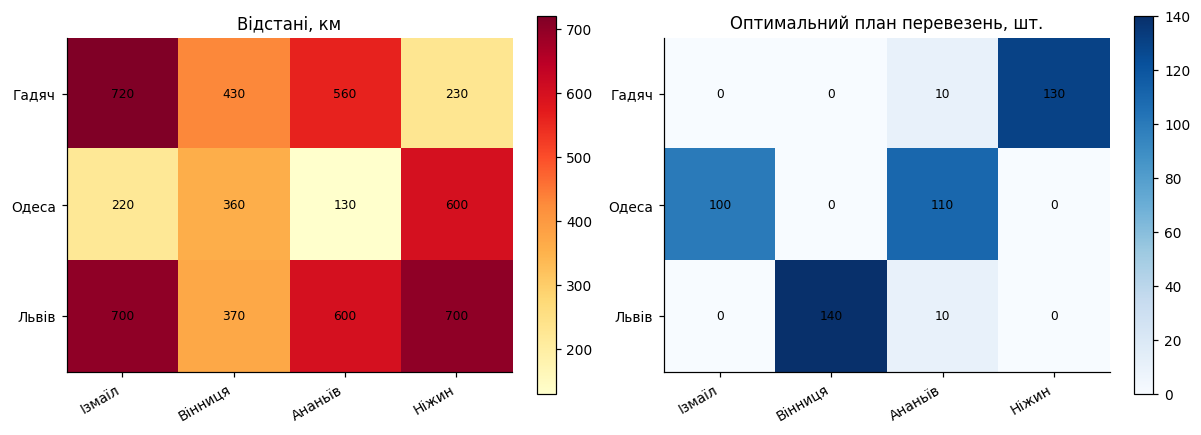

In [18]:
# ВАШ КОД
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

im0 = axes[0].imshow(D, cmap='YlOrRd')
axes[0].set_xticks(range(n)); axes[0].set_xticklabels(споживачі, rotation=30, ha='right')
axes[0].set_yticks(range(m)); axes[0].set_yticklabels(постачальники)
axes[0].set_title('Відстані, км')
for i in range(m):
    for j in range(n):
        axes[0].text(j, i, int(D[i, j]), ha='center', va='center', fontsize=8)
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(X1, cmap='Blues')
axes[1].set_xticks(range(n)); axes[1].set_xticklabels(споживачі, rotation=30, ha='right')
axes[1].set_yticks(range(m)); axes[1].set_yticklabels(постачальники)
axes[1].set_title('Оптимальний план перевезень, шт.')
for i in range(m):
    for j in range(n):
        axes[1].text(j, i, int(round(X1[i, j])), ha='center', va='center', fontsize=8)
plt.colorbar(im1, ax=axes[1], fraction=0.046)

fig.tight_layout()
plt.show()


**Висновок:** маршрути з найменшою вартістю на лівій теплокарті (Одеса-Ізмаїл, Одеса-Ананьїв) - це якраз ті самі клітинки, які на правій теплокарті отримали найбільші обсяги перевезень (100 і 110 шт.), а найдорожчий записаний маршрут (Львів—Ніжин, 700 км) узагалі не використовується - солвер природно спрямовує потік туди, де це найдешевше, а надлишок з дорогих напрямків «закриває» лише те, що більше нічим закрити (Гадяч-Ніжин і Львів-Вінниця).


---
# Етап 12. Декларація про використання інструментів штучного інтелекту

Користуватися мовними моделями **дозволено**. Обов'язковою є прозорість.
Порушенням є не використання інструмента, а нездатність пояснити власний код
і власні числа на захисті.

Для кожного етапу оберіть одне: `'ні'`, `'синтаксис'`, `'код, перевірено'`,
`'текст, перероблено'`, `'текст, як є'`.

In [19]:
ІНСТРУМЕНТИ_ШІ = 'Claude'

ДЕКЛАРАЦІЯ = {
    'етап 1, формалізація моделі':          'код, перевірено',
    'етап 2, побудова моделі в Excel':      'код, перевірено',
    'етап 3, код на Python':                'код, перевірено',
    'етапи 4–5, читання та перевірка звіту': 'код, перевірено',
    'етап 6, рішення про закупівлю':        'код, перевірено',
    'етапи 7–8, перевірка та цілочисельність': 'код, перевірено',
    'етапи 9–11, транспортна задача':       'код, перевірено',
}

# Що саме ви перевірили за згенерованим кодом чи текстом — конкретно.
ЩО_ПЕРЕВІРЕНО = ('Перевірив тіньові ціни та допустимі діапазони прямим перерахунком LP при '
                  'зміщеному запасі ресурсу (етапи 4–5), а не повірив числам на слово. Звірив '
                  'округлений план із цілочисельним оптимумом через integrality=1. Для '
                  'транспортної задачі перерахував потенціали вручну методом u-v з іншим '
                  'опорним вузлом і переконався, що різниця постійна — це і є доказ формули '
                  'з лекції про лінійну залежність одного з обмежень балансу.')

# True означає: я можу пояснити кожен рядок свого коду, відтворити будь-яке число
# цієї роботи та внести зміни в модель на вимогу під час захисту.
ПІДТВЕРДЖУЮ = True


In [20]:
# --- перевірка повноти декларації: клітинку не редагувати --------------------
ДОЗВОЛЕНІ = {'ні', 'синтаксис', 'код, перевірено', 'текст, перероблено', 'текст, як є'}
assert ІНСТРУМЕНТИ_ШІ.strip(), 'Вкажіть інструменти або напишіть «не використовував»'
порожні = [k for k, v in ДЕКЛАРАЦІЯ.items() if not str(v).strip()]
assert not порожні, 'Не заповнено: %s' % '; '.join(порожні)
чужі = {v for v in ДЕКЛАРАЦІЯ.values() if v not in ДОЗВОЛЕНІ}
assert not чужі, 'Недопустимі значення: %s' % ', '.join(sorted(чужі))
assert len(ЩО_ПЕРЕВІРЕНО.strip()) >= 120, ('Опишіть конкретніше (зараз %d символів, '
                                           'потрібно щонайменше 120)' % len(ЩО_ПЕРЕВІРЕНО.strip()))
assert ПІДТВЕРДЖУЮ is True, 'Підтвердьте, що можете пояснити власний код на захисті'
print('ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ')
print('=' * 78)
print('%-42s %s' % ('автор:', ПІБ))
print('%-42s %s' % ('інструменти:', ІНСТРУМЕНТИ_ШІ))
print('-' * 78)
for k, v in ДЕКЛАРАЦІЯ.items():
    print('%-42s %s' % (k + ':', v))
print('-' * 78)
print(ЩО_ПЕРЕВІРЕНО)

ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ
автор:                                     Голейчук Іван Миколайович
інструменти:                               Claude
------------------------------------------------------------------------------
етап 1, формалізація моделі:               код, перевірено
етап 2, побудова моделі в Excel:           код, перевірено
етап 3, код на Python:                     код, перевірено
етапи 4–5, читання та перевірка звіту:     код, перевірено
етап 6, рішення про закупівлю:             код, перевірено
етапи 7–8, перевірка та цілочисельність:   код, перевірено
етапи 9–11, транспортна задача:            код, перевірено
------------------------------------------------------------------------------
Перевірив тіньові ціни та допустимі діапазони прямим перерахунком LP при зміщеному запасі ресурсу (етапи 4–5), а не повірив числам на слово. Звірив округлений план із цілочисельним оптимумом через integrality=1. Для транспортної задачі перерахував потенціали вручну 

---
# Крок 13. Фінальна самоперевірка

In [21]:
перевірки = {
    'ПІБ і варіант заповнено':            bool(ПІБ) and 1 <= ВАРІАНТ <= 30,
    'Excel і Python дали однаковий план': abs(прибуток - EXCEL_ПРИБУТОК) < 0.5,
    'перевірку «ненульові = зв’язні» зроблено': ненульових == звязних,
    'дані транспортної задачі введено':   len(постачальники) == 3 and len(споживачі) == 4,
    'баланс запасів і попиту':            sum(запас) == sum(попит),
    'декларацію заповнено':               bool(ІНСТРУМЕНТИ_ШІ.strip()) and ПІДТВЕРДЖУЮ is True,
}
for k, v in перевірки.items():
    print(('OK   ' if v else 'НЕ ОК') + '  ' + k)
if all(перевірки.values()):
    print('\nТехнічна частина виконана.')
    print('Переконайтеся, що заповнені ВСІ клітинки з відповідями,')
    print('і виконайте Kernel → Restart & Run All перед здачею.')

OK     ПІБ і варіант заповнено
OK     Excel і Python дали однаковий план
OK     перевірку «ненульові = зв’язні» зроблено
OK     дані транспортної задачі введено
OK     баланс запасів і попиту
OK     декларацію заповнено

Технічна частина виконана.
Переконайтеся, що заповнені ВСІ клітинки з відповідями,
і виконайте Kernel → Restart & Run All перед здачею.
